# Урок 4. Метрики качества классификации ч.2

Продолжим работу с метриками классификации. В предыдущем задании мы разобрали матрицу ошибок и две основные метрики, которые используются при бинарной классификации.

Сейчас рассмотрим F-меру - совокупную метрику по precision и recall - и более сложную AUC-ROC.

### 2.1
Из задания к предыдущему уроку выберите классификатор, который давал наименьшее значение recall, вычислите для него precision, применив precision_score, и самостоятельно посчитайте F1-меру (расчеты должны присутствовать). Затем проверьте ответ, используя встроенную функцию.

Сравните полученную f1-меру со значением среднего арифметического полноты и точности.

In [8]:
from sklearn.metrics import precision_score, f1_score
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split

from sklearn.metrics import confusion_matrix, recall_score
from sklearn.metrics import accuracy_score
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression

In [9]:
df = pd.read_csv('train.csv')
#заменяем значения в столбцах Cabin и Embarked
df['Cabin'] = df['Cabin'].fillna('U')
df['Embarked'] = df['Embarked'].fillna('U')

#группируем столбец age по полу и применяем функцию apply к столбцу age
df['Age'] = df.groupby('Sex')['Age'].apply(lambda x: x.fillna(x.median())).reset_index(drop=True)
missing_values = df.isnull().sum()   
#print(missing_values)

#замена значений в колонке Sex
df['Sex'] = df['Sex'].map({'male': 0, 'female': 1})

#замена значений в колонке Embarked
df['Embarked'] = df['Embarked'].map({'U': 0, 'S': 1, 'C': 2, 'Q': 3})

#отбрасываем ненужные колонки
df = df.drop(['PassengerId', 'Name', 'Ticket', 'Cabin'], axis=1)

passenger_dataset = df.drop('Pclass', axis=1)  #удаляем целевую переменную из признаков
#целевая переменная
y = df['Pclass']

#разделяем на обучающую и тестовую выборки
x_train, x_test, y_train, y_test = train_test_split(passenger_dataset, y, test_size=0.25, random_state=17)
#print(f'X_train shape: {x_train.shape}, y_train shape: {y_train.shape},\n'
#      f'X_test shape: {x_test.shape}, y_test shape: {y_test.shape}')

#обучение по методу GaussianNB
nb = GaussianNB()
nb_model = nb.fit(x_train, y_train)
nb_predictions = nb.predict(x_test)

#получаем матрицу ошибок
cm = confusion_matrix(y_test, nb_predictions)
print("Матрица ошибок:")
print(cm)

#Recall для каждого класса
recall_0 = cm[0, 0] / np.sum(cm[0, :])  
recall_1 = cm[1, 1] / np.sum(cm[1, :])  
recall_2 = cm[2, 2] / np.sum(cm[2, :])  

print(f"Recall класса 0: {recall_0:.4f} = {cm[0, 0]} / {np.sum(cm[0, :])}")
print(f"Recall класса 1: {recall_1:.4f} = {cm[1, 1]} / {np.sum(cm[1, :])}")
print(f"Recall класса 2: {recall_2:.4f} = {cm[2, 2]} / {np.sum(cm[2, :])}")

#Macro recall
macro_recall_manual = (recall_0 + recall_1 + recall_2) / 3
print(f"Macro recall (среднее): {macro_recall_manual:.4f}")

#проверка встроенной функцией  recall_score
recall_macro = recall_score(y_test, nb_predictions, average='macro')
recall_per_class = recall_score(y_test, nb_predictions, average=None)

print(f"\nRecall по классам (sklearn): {recall_per_class}")
print(f"Macro recall (sklearn): {recall_macro:.4f}")

best_precision = precision_score(y_test, nb_predictions, average='macro')
print(f"Precision модели nb: {best_precision:.4f}")

Матрица ошибок:
[[ 37  13   4]
 [  1  26  21]
 [  4  16 101]]
Recall класса 0: 0.6852 = 37 / 54
Recall класса 1: 0.5417 = 26 / 48
Recall класса 2: 0.8347 = 101 / 121
Macro recall (среднее): 0.6872

Recall по классам (sklearn): [0.68518519 0.54166667 0.83471074]
Macro recall (sklearn): 0.6872
Precision модели nb: 0.7184


In [41]:
df.head(10)

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,0,3,0,38.0,1,0,7.2500,1
1,1,1,1,26.0,1,0,71.2833,2
2,1,3,1,35.0,0,0,7.9250,1
3,1,1,1,27.0,1,0,53.1000,1
4,0,3,0,14.0,0,0,8.0500,1
5,0,3,0,4.0,0,0,8.4583,3
6,0,1,0,58.0,0,0,51.8625,1
7,0,3,0,14.0,3,1,21.0750,1
8,1,3,1,55.0,0,2,11.1333,1
9,1,2,1,31.0,1,0,30.0708,2


In [13]:
#вычисляем F1-меру вручную из precision и recall
manual_f1 = 2 * (best_precision * macro_recall_manual) / (best_precision + macro_recall_manual)
print(f"F1-мера (ручной расчет): {manual_f1:.4f}")
#вычисляем F1-меру с помощью встроенной функции
f1_macro = f1_score(y_test, nb_predictions, average='macro')
print(f"F1-мера (встроенная): {f1_macro:.4f}")
#вычисляем среднее арифметическое значение полноты и точности
arithmetic_mean = (best_precision + macro_recall_manual) / 2
print(f"Среднее арифметическое: {arithmetic_mean:.4f}")

F1-мера (ручной расчет): 0.7025
F1-мера (встроенная): 0.6978
Среднее арифметическое: 0.7028


В библиотеке sklearn есть удобная функция classification_report, возвращающая precision, recall, F-меру и количество экземпляров каждого класса в удобном для чтения формате. Также существует функция precision_recall_fscore_support, возвращающая те же самые метрики, но в форме массива.

### 2.2
Для каждого классификатора из предыдущего урока рассчитайте и выведите следующие импортированные метрики.

In [14]:
from sklearn.metrics import precision_recall_fscore_support, classification_report

In [18]:
#использование classification_report
report = classification_report(y_test, nb_predictions)
print(f"classification report nb predictions: {report}")

classification report nb predictions:               precision    recall  f1-score   support

           1       0.88      0.69      0.77        54
           2       0.47      0.54      0.50        48
           3       0.80      0.83      0.82       121

    accuracy                           0.74       223
   macro avg       0.72      0.69      0.70       223
weighted avg       0.75      0.74      0.74       223



In [21]:
#Использование precision_recall_fscore_support
precision, recall, fscore, support = precision_recall_fscore_support(y_test, nb_predictions)

metrics_df = pd.DataFrame({
    'Class': [0, 1, 2],
    'Precision': precision,
    'Recall': recall,
    'F1-Score': fscore,
    'Support': support
})
print(metrics_df)

   Class  Precision    Recall  F1-Score  Support
0      0   0.880952  0.685185  0.770833       54
1      1   0.472727  0.541667  0.504854       48
2      2   0.801587  0.834711  0.817814      121


In [24]:
#обучение по методу ближайших соседей и записывание предсказаний в переменную
knn = KNeighborsClassifier(n_neighbors=5)
knn_model = knn.fit(x_train, y_train)
knn_predictions = knn.predict(x_test)

In [25]:
#использование classification_report
report = classification_report(y_test, knn_predictions)
print(f"classification report nb predictions: {report}")

classification report nb predictions:               precision    recall  f1-score   support

           1       0.71      0.83      0.77        54
           2       0.62      0.52      0.57        48
           3       0.85      0.84      0.85       121

    accuracy                           0.77       223
   macro avg       0.73      0.73      0.73       223
weighted avg       0.77      0.77      0.77       223



In [26]:
#Использование precision_recall_fscore_support
precision, recall, fscore, support = precision_recall_fscore_support(y_test, knn_predictions)

metrics_df = pd.DataFrame({
    'Class': [0, 1, 2],
    'Precision': precision,
    'Recall': recall,
    'F1-Score': fscore,
    'Support': support
})
print(metrics_df)

   Class  Precision    Recall  F1-Score  Support
0      0   0.714286  0.833333  0.769231       54
1      1   0.625000  0.520833  0.568182       48
2      2   0.850000  0.842975  0.846473      121


In [27]:
#обучение по методу дерева решений
dtc = DecisionTreeClassifier()
dtc_model = dtc.fit(x_train, y_train)
dtc_predictions = dtc.predict(x_test)

In [28]:
#использование classification_report
report = classification_report(y_test, dtc_predictions)
print(f"classification report nb predictions: {report}")

classification report nb predictions:               precision    recall  f1-score   support

           1       0.91      0.80      0.85        54
           2       0.69      0.75      0.72        48
           3       0.92      0.94      0.93       121

    accuracy                           0.87       223
   macro avg       0.84      0.83      0.83       223
weighted avg       0.87      0.87      0.87       223



In [29]:
#Использование precision_recall_fscore_support
precision, recall, fscore, support = precision_recall_fscore_support(y_test, dtc_predictions)

metrics_df = pd.DataFrame({
    'Class': [0, 1, 2],
    'Precision': precision,
    'Recall': recall,
    'F1-Score': fscore,
    'Support': support
})
print(metrics_df)

   Class  Precision    Recall  F1-Score  Support
0      0   0.914894  0.796296  0.851485       54
1      1   0.692308  0.750000  0.720000       48
2      2   0.919355  0.942149  0.930612      121


In [30]:
#обучение по методу LogisticRegression
lr = LogisticRegression(random_state=17, max_iter=1000)
lr_model = lr.fit(x_train, y_train)
lr_predictions = lr.predict(x_test)

In [31]:
#использование classification_report
report = classification_report(y_test, lr_predictions)
print(f"classification report nb predictions: {report}")

classification report nb predictions:               precision    recall  f1-score   support

           1       0.86      0.81      0.84        54
           2       0.76      0.52      0.62        48
           3       0.83      0.95      0.88       121

    accuracy                           0.83       223
   macro avg       0.82      0.76      0.78       223
weighted avg       0.82      0.83      0.82       223



In [32]:
#Использование precision_recall_fscore_support
precision, recall, fscore, support = precision_recall_fscore_support(y_test, lr_predictions)

metrics_df = pd.DataFrame({
    'Class': [0, 1, 2],
    'Precision': precision,
    'Recall': recall,
    'F1-Score': fscore,
    'Support': support
})
print(metrics_df)

   Class  Precision    Recall  F1-Score  Support
0      0   0.862745  0.814815  0.838095       54
1      1   0.757576  0.520833  0.617284       48
2      2   0.827338  0.950413  0.884615      121


Вернемся к классификатору LogisticRegression, который мы обучали в предыдущем задании. Там мы не затрагивали настройку гиперпараметров: сделать это можно с помощью LogisticRegressionCV - перебора параметров по сетке с последующей кросс-валидацией (по сути это аналог GridSearchCV, но со своими параметрами внутри, применимыми только к логистической регрессии). Этот класс создан специально для логистической регрессии, т.к. для нее известны эффективные алгоритмы перебора параметров.

У LogisticRegression есть гиперпараметр C - обратный коэффициент регуляризации. Не вдаваясь в подробное описание по формуле, можно сказать, что C соответствует "сложности" модели: чем больше C, тем более сложные зависимости может восстанавливать модель; если параметр C слишком мал (слишком сильная регуляризация), то модель окажется недообученной, а если наоборот регуляризация слишком слабая (т.е. C принимает большие значения), то скорее всего модель окажется переобученной, потому как модель будет слишком "бояться" ошибиться на обучающей выборке.

### 2.3

1. Используя StratifiedKFold, разбейте данные для кросс-валидации по 5-ти блокам (не забывайте во всех методах использовать random_state=17).
2. С помощью numpy.logspace разбейте интервал (-1, 2) на 500 значений.
3. С помощью LogisticRegressionCV подберите оптимальный параметр C: установите гиперпараметр Cs равным объекту из п.2 (разбиение интервала (-1, 2) отвечает за подбор обратного коэффициента регуляризации C); cv равным объекту из п.1 (разбиение для кросс-валидации); scoring равным "roc_auc" (отвечает за оптимизацию гиперпараметров на кросс-валидации: метрика, установленная в scoring, контролирует, как оценивать модель при каждом из наборе параметров, т.е. показывает, какая метрика должна быть наилучшей).
4. Обучите полученную модель на тренировочных данных.

In [43]:
from sklearn.model_selection import StratifiedKFold
from sklearn.linear_model import LogisticRegressionCV
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.multiclass import OneVsRestClassifier

In [63]:
#разбивка данных на тренировочные и тестовые
x_train, x_test, y_train, y_test = train_test_split(passenger_dataset, y, test_size=0.25, random_state=17)

#разбивка данных для кросс-валидации
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=17)
#создание логарифмической шкалы для параметра C
Cs = np.logspace(-1, 2, 500)
print(f"Диапазон параметра C: от {Cs[0]} до {Cs[-1]}")
print(f"Количество значений C: {len(Cs)}")

Диапазон параметра C: от 0.1 до 100.0
Количество значений C: 500


In [93]:
#распределение классов в y_train - проверка
print(y_train.value_counts(normalize=True))
#создание и обучение LogisticRegressionCV с добавлением class_weight='balanced' при наличии дисбаланса классов
logreg_cv = OneVsRestClassifier(LogisticRegressionCV(Cs=Cs, cv=skf, scoring='roc_auc', random_state=17, max_iter=1000, class_weight='balanced'))
#масштабирование данных, т.к. признаки имеют разный масштаб
scaler = StandardScaler()
x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)

Pclass
3    0.553892
1    0.242515
2    0.203593
Name: proportion, dtype: float64


In [65]:
from sklearn.feature_selection import mutual_info_classif

#анализ важности признаков перед обучением
mi_scores = mutual_info_classif(x_train_scaled, y_train)
feature_names = passenger_dataset.columns
for i, (score, name) in enumerate(zip(mi_scores, feature_names)):
    print(f"{name}: {score:.4f}")

Survived: 0.0575
Sex: 0.0101
Age: 0.0073
SibSp: 0.0085
Parch: 0.0000
Fare: 0.7713
Embarked: 0.0937


In [134]:
#удаляем признаки с низкой информативностью
features_to_drop = ['Parch', 'Sex', 'Age', 'SibSp'] 
passenger_dataset_reduced = passenger_dataset.drop(features_to_drop, axis=1)

#используем DF с отфильтрованными признаками
x_train, x_test, y_train, y_test = train_test_split(passenger_dataset_reduced, y, test_size=0.25, random_state=17)


In [135]:
#масштабируем отфильтрованные признаки
scaler = StandardScaler()
x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)

In [136]:
#анализируем важность признаков
mi_scores = mutual_info_classif(x_train_scaled, y_train)
feature_names = passenger_dataset_reduced.columns
for i, (score, name) in enumerate(zip(mi_scores, feature_names)):
    print(f"{name}: {score:.4f}")

Survived: 0.0650
Fare: 0.7744
Embarked: 0.0790


In [137]:
#берем разбивку с кросс-валидацией
logreg_cv = OneVsRestClassifier(LogisticRegressionCV(Cs=Cs, cv=skf, scoring='roc_auc', random_state=17, max_iter=1000, class_weight='balanced'))

#обучение модели
logreg_cv_model = logreg_cv.fit(x_train_scaled, y_train)


In [138]:
#после обучения модели добавляем проверку:
best_Cs = [estimator.C_[0] for estimator in logreg_cv_model.estimators_]
if max(best_Cs) / min(best_Cs) > 10:
    print(f"Отношение MAX к MIN С = {max(best_Cs) / min(best_Cs):.4f} нужна коррекция!")
else:
    print(f"Отношение MAX к MIN С = {max(best_Cs) / min(best_Cs):.4f} коррекция не нужна!")

Отношение MAX к MIN С = 4.5218 коррекция не нужна!


In [69]:
#расширяем диапазон поиска C
#Cs_extended = np.logspace(-3, 4, 500) #увеличиваем интервал
#print(f"Новый диапазон C: от {Cs_extended[0]:.4f} до {Cs_extended[-1]:.4f}")
#print(f"Количество значений C: {len(Cs_extended)}")
#переобучаем модель с расширенным диапазоном
#logreg_cv_extended = OneVsRestClassifier(LogisticRegressionCV(Cs=Cs_extended, cv=skf, scoring='roc_auc', random_state=17, max_iter=1000, class_weight='balanced'))

Новый диапазон C: от 0.0010 до 10000.0000
Количество значений C: 500


In [70]:
#масштабируем отфильтрованные признаки
#scaler = StandardScaler()
#x_train_scaled = scaler.fit_transform(x_train)
#x_test_scaled = scaler.transform(x_test)

In [71]:
#обучение модели
#logreg_cv = OneVsRestClassifier(LogisticRegressionCV(Cs=Cs, cv=skf, scoring='roc_auc', random_state=17, max_iter=1000, class_weight='balanced'))
#logreg_cv_model = logreg_cv_extended.fit(x_train_scaled, y_train)

### 2.4
Используя метод plot из matplotlib.pyplot, выведите график зависимости auc_roc от значения C.

*Примечание: значения по оси x - разбиение с помощью np.logspace из п.2 предыдущего задания, а значения по оси y - среднее значение roc_auc по каждой валидации, т.е. среднее значение из полученных на каждом из 5-ти разбиений при данном параметре C (используйте метод scores_ объекта, который инкапсулирует LogisticRegressionCV).*

In [23]:
import matplotlib.pyplot as plt

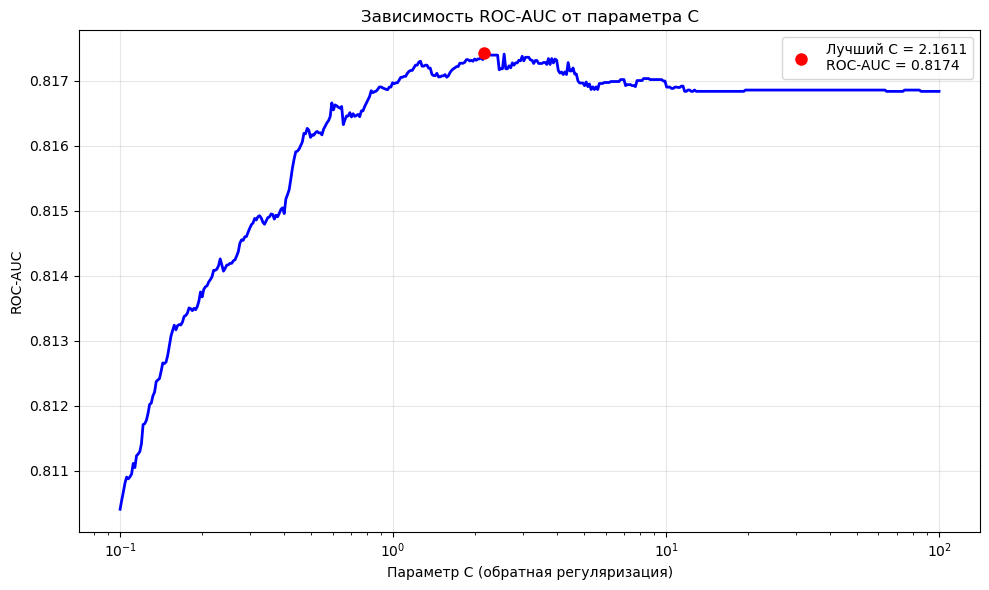

In [139]:
#получаем количество классов
n_classes = len(logreg_cv_model.estimators_)

#собираем все scores для каждого класса
all_scores = []
for i in range(n_classes):
    #для каждого класса извлекаем scores_ из LogisticRegressionCV
    scores_class_i = logreg_cv_model.estimators_[i].scores_[1] 
    all_scores.append(scores_class_i)

#усредняем по фолдам
mean_scores_per_class = [scores.mean(axis=0) for scores in all_scores]
#усредняем по классам
mean_scores = np.mean(mean_scores_per_class, axis=0)  

#берем значения C из первого классификатора
Cs_plot = logreg_cv_model.estimators_[0].Cs_

#визуализация
plt.figure(figsize=(10, 6))
plt.plot(Cs_plot, mean_scores, 'b-', linewidth=2)
plt.xscale('log')
plt.xlabel('Параметр C (обратная регуляризация)')
plt.ylabel('ROC-AUC')
plt.title('Зависимость ROC-AUC от параметра C')
plt.grid(True, alpha=0.3)
#визуализация лучшего С
best_idx = np.argmax(mean_scores)
plt.plot(Cs_plot[best_idx], mean_scores[best_idx], 'ro', markersize=8, label=f'Лучший C = {Cs_plot[best_idx]:.4f}\nROC-AUC = {mean_scores[best_idx]:.4f}')
plt.legend()
plt.tight_layout()
plt.show()


### 2.5
С помощью метода C_ того же объекта выведите лучшее значение C. Выведите более конкретную область графика (область ~15 точкам по x), включающую лучшее значение C.

*Примечание: используйте plt.xlim.*

In [140]:
#находим лучшее значение C (усредненное по всем классам)
best_Cs = [estimator.C_[0] for estimator in logreg_cv_model.estimators_]
best_C_mean = np.mean(best_Cs)

print("Лучшие значения C для каждого класса:")
for i, C_val in enumerate(best_Cs):
    print(f"Класс {i}: C = {C_val:.4f}")
print(f"Среднее значение C: {best_C_mean:.4f}")


Лучшие значения C для каждого класса:
Класс 0: C = 3.7080
Класс 1: C = 5.6952
Класс 2: C = 1.2595
Среднее значение C: 3.5542


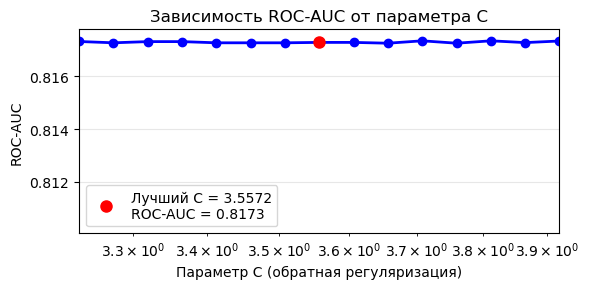

In [141]:
#находим индекс ближайшего значения C в массиве Cs_plot к среднему значению
best_idx = np.argmin(np.abs(Cs_plot - best_C_mean))

#определяем область для увеличенного графика (15 точек вокруг лучшего C)
window_size = 15
start_idx = max(0, best_idx - window_size // 2)
end_idx = min(len(Cs_plot), best_idx + window_size // 2 + 1)
#визуализация
plt.figure(figsize=(6, 3))
plt.plot(Cs_plot, mean_scores, 'b-', linewidth=2, marker='o')
plt.xscale('log')
plt.xlabel('Параметр C (обратная регуляризация)')
plt.ylabel('ROC-AUC')
plt.title('Зависимость ROC-AUC от параметра C')
plt.grid(True, alpha=0.3)

#устанавливаем границы для увеличенной области
plt.xlim(Cs_plot[start_idx], Cs_plot[end_idx-1])
#визуализация лучшего С
plt.plot(Cs_plot[best_idx], mean_scores[best_idx], 'ro', markersize=8, label=f'Лучший C = {Cs_plot[best_idx]:.4f}\nROC-AUC = {mean_scores[best_idx]:.4f}')
plt.legend()
plt.tight_layout()
plt.show()

### 2.6
С помощью метода predict_proba получите вероятности принадлежности объектов тестовой выборки к классам. Постройте график roc_auc для тестовой выборки и выведите значение auc.

**Пример** построения графика.

In [35]:
from sklearn.metrics import roc_auc_score, roc_curve

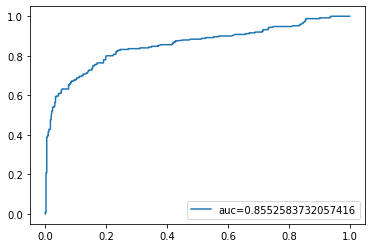

In [ ]:
probas = logit_search.fit(x_train, y_train).predict_proba(x_train)
fpr, tpr, _ = roc_curve(y_train, probas[:, 1])
auc = roc_auc_score(y_train, probas[:, 1])
plt.plot(fpr, tpr, label="auc=" + str(auc))
plt.legend(loc=4)

AUC = 0.2347
AUC < 0.5 - модель работает хуже случайного классификатора
Меняем местами вероятности для положительного и отрицательного классов


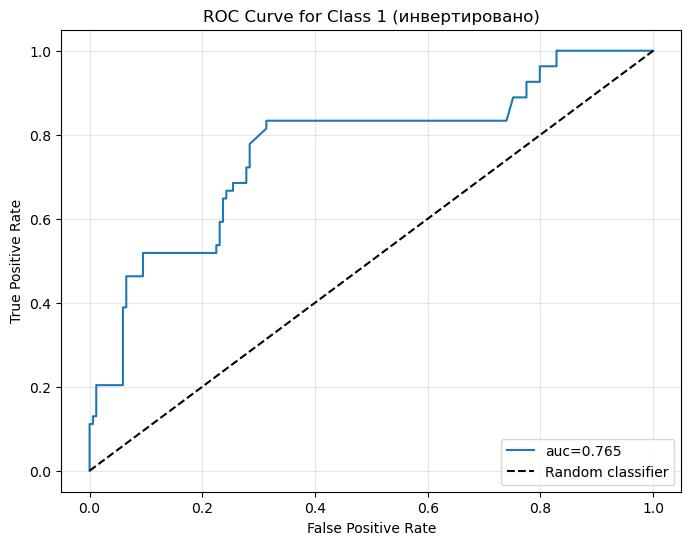

ROC-AUC: 0.7653


In [142]:
#выбор класса для анализа
class_idx = 1

#получаем вероятности
probas = logreg_cv_model.predict_proba(x_test_scaled)

#создаем бинарные метки для выбранного класса
y_binary = (y_test == class_idx).astype(int)

#вычисляем ROC точки кривой и AUC площадь
fpr, tpr, thresholds = roc_curve(y_binary, probas[:, class_idx])
auc_score = roc_auc_score(y_binary, probas[:, class_idx])

#если AUC < 0.5, меняем местами вероятности для положительного и отрицательного классов
if auc_score < 0.5:
    print(f"AUC = {auc_score:.4f}")
    print("AUC < 0.5 - модель работает хуже случайного классификатора")
    print("Меняем местами вероятности для положительного и отрицательного классов")
    #вычисляем ROC точки кривой и AUC площадь
    fpr, tpr, thresholds = roc_curve(y_binary, 1 - probas[:, class_idx])
    auc_score_corrected = roc_auc_score(y_binary, 1 - probas[:, class_idx])
    
    plt.figure(figsize=(8, 6))
    plt.plot(fpr, tpr, label="auc=" + str(round(auc_score_corrected, 3)))
    plt.plot([0, 1], [0, 1], 'k--', label='Random classifier')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title(f'ROC Curve for Class {class_idx} (инвертировано)')
    plt.legend(loc=4)
    plt.grid(alpha=0.3)
    plt.show()
    
    print(f"ROC-AUC: {auc_score_corrected:.4f}")